# Getriebe-Analyse Task 2
In diesem Notebook werden die Signaldaten aus Task 2 geladen und analysiert. Die Metadaten werden aus den Dateinamen extrahiert, um eine eindeutige Zuordnung der Signale zu Probe (spec), Position (pos) und Messreihen (mID/rID) zu ermöglichen.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from dataframe_manager import DataFrameManager

# Pfad zum Datenordner in Task 2
data_path = '../data'

# Initialisierung des Managers und Laden der Signale
manager = DataFrameManager(data_dir=data_path)
manager.load_signals()

# Dataframe abrufen
df = manager.get_dataframe()
print(f"Erfolgreich {len(df)} Signale geladen.")
df.head()

Erfolgreich 440 Signale geladen.


,fn,sig,fs,spec,pos,mID,time,rID,sID
0,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...,"[0.00048828125, 0.00244140625, 0.0029296875, 0...",1041666,Z01,Pos00,0000,1307031427,00000,Ch1
1,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...,"[0.001953125, 0.0, 0.00146484375, 0.001953125,...",1041666,Z01,Pos00,0000,1307031427,00000,Ch2
2,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...",1041666,Z01,Pos00,0000,1307031427,00001,Ch1
3,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...,"[-0.00048828125, 0.0009765625, 0.0, -0.0009765...",1041666,Z01,Pos00,0000,1307031427,00001,Ch2
4,Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...,"[0.00048828125, 0.00146484375, 0.00048828125, ...",1041666,Z01,Pos00,0001,1312091511,00000,Ch1


### Zelle 2: Feature-Extraktion und PCA
In dieser Zelle werden physikalische und psychoakustische Merkmale extrahiert, um den Zustand der Zahnräder statistisch beschreibbar zu machen.

#### 1. Spektrale Merkmale (Frequenzbereich)
*   **MFCCs (13 Koeffizienten):** Bilden die Spektraleinhüllende auf der Mel-Skala ab (ähnlich dem menschlichen Gehör).
*   **Spectral Centroid (Schwerpunkt):** Gibt an, bei welcher Frequenz der "Masseschwerpunkt" des Spektrums liegt. Ein Maß für die "Helligkeit" des Klangs.
    *   *Formel:* $f_c = \frac{\sum f \cdot P(f)}{\sum P(f)}$
*   **Spectral Bandwidth (Bandbreite):** Beschreibt die Spreizung des Spektrums um den Schwerpunkt.
*   **Spectral Roll-off:** Die Frequenz, unter der ein bestimmter Prozentsatz (meist 85%) der Spektralenergie liegt.
*   **Spectral Contrast:** Misst den Unterschied zwischen Spitzen und Tälern im Spektrum.
*   **Chroma Features (STFT/CENS):** Projizieren das gesamte Spektrum auf 12 Halbtonklassen.

#### 2. Zeitbereichs-Merkmale
*   **Zero Crossing Rate (ZCR):** Die Rate, mit der das Signal die Nulllinie kreuzt. Ein Maß für die Frequenz und Impulsivität (Rauschen).
    *   *Formel:* $ZCR = \frac{1}{2N} \sum_{n=1}^{N-1} |sign(x[n]) - sign(x[n-1])|$
*   **Frame Energy (RMS):** Der quadratische Mittelwert der Amplitude.
    *   *Formel:* $x_{rms} = \sqrt{\frac{1}{N} \sum x_i^2}$

#### 3. Dynamische Merkmale
*   **Delta-Features:** Die erste zeitliche Ableitung der MFCCs.

#### 4. PCA (Hauptkomponentenanalyse)
Die PCA reduziert diesen hochdimensionalen Merkmalsraum auf **zwei Komponenten (PC1 & PC2)**. Zuvor werden alle Merkmale **standardisiert** (Mittelwert 0, Varianz 1).

In [3]:
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Globale Variable initialisieren, um NameError in Folgezellen zu vermeiden
pca_var_ratio = [0.0, 0.0]

def extract_features_comprehensive(df):
    all_features = []
    n_fft, hop_length, fmax = 4096, 1024, 200000
    
    print("Extrahiere Merkmale für 440 Signale...")
    for i, row in df.iterrows():
        sig, fs = row['sig'], row['fs']
        try:
            # Spektral
            mfcc = librosa.feature.mfcc(y=sig, sr=fs, n_mfcc=13, n_fft=n_fft, hop_length=hop_length, fmax=fmax)
            centroid = librosa.feature.spectral_centroid(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            bandwidth = librosa.feature.spectral_bandwidth(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            rolloff = librosa.feature.spectral_rolloff(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            contrast = librosa.feature.spectral_contrast(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length, fmin=200)
            chroma_stft = librosa.feature.chroma_stft(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            chroma_cens = librosa.feature.chroma_cens(y=sig, sr=fs, hop_length=hop_length)
            
            # Zeit & Dynamik
            zcr = librosa.feature.zero_crossing_rate(sig, frame_length=n_fft, hop_length=hop_length)
            energy = librosa.feature.rms(y=sig, frame_length=n_fft, hop_length=hop_length)
            delta_mfcc = librosa.feature.delta(mfcc)
            
            vector = np.hstack([
                np.mean(mfcc, axis=1), np.mean(centroid), np.mean(bandwidth), 
                np.mean(rolloff), np.mean(contrast, axis=1), 
                np.mean(chroma_stft, axis=1), np.mean(chroma_cens, axis=1), 
                np.mean(zcr), np.mean(energy), np.mean(delta_mfcc, axis=1)
            ])
            all_features.append(vector)
        except Exception: continue
    return np.array(all_features)

features_matrix = extract_features_comprehensive(df)
X = pd.DataFrame(features_matrix).apply(pd.to_numeric, errors='coerce').fillna(0)
X = X.loc[:, (X.std() > 1e-10)]

if X.shape[1] > 0:
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    results = pca.fit_transform(X_scaled)
    df['PC1'], df['PC2'] = results[:, 0], results[:, 1]
    pca_var_ratio = pca.explained_variance_ratio_ * 100
    print(f"PCA abgeschlossen. Merkmale: {X.shape[1]}. Varianz: {np.sum(pca.explained_variance_ratio_):.2%}")
else:
    print("Fehler: Keine variablen Merkmale gefunden.")
df[['spec', 'pos', 'mID', 'PC1', 'PC2']].head()

Extrahiere Merkmale für 440 Signale...
PCA abgeschlossen. Merkmale: 55. Varianz: 37.43%


,spec,pos,mID,PC1,PC2
0,Z01,Pos00,0000,1.962044,-1.035491
1,Z01,Pos00,0000,-3.593912,0.130516
2,Z01,Pos00,0000,0.792450,-1.261707
3,Z01,Pos00,0000,-5.279511,-0.057707
4,Z01,Pos00,0001,1.828636,-2.683074


### Zelle 3: Stabilitätsanalyse (rID & mID Vergleich)
Visualisierung der Reproduzierbarkeit und zeitlichen Stabilität (vertikales Layout).

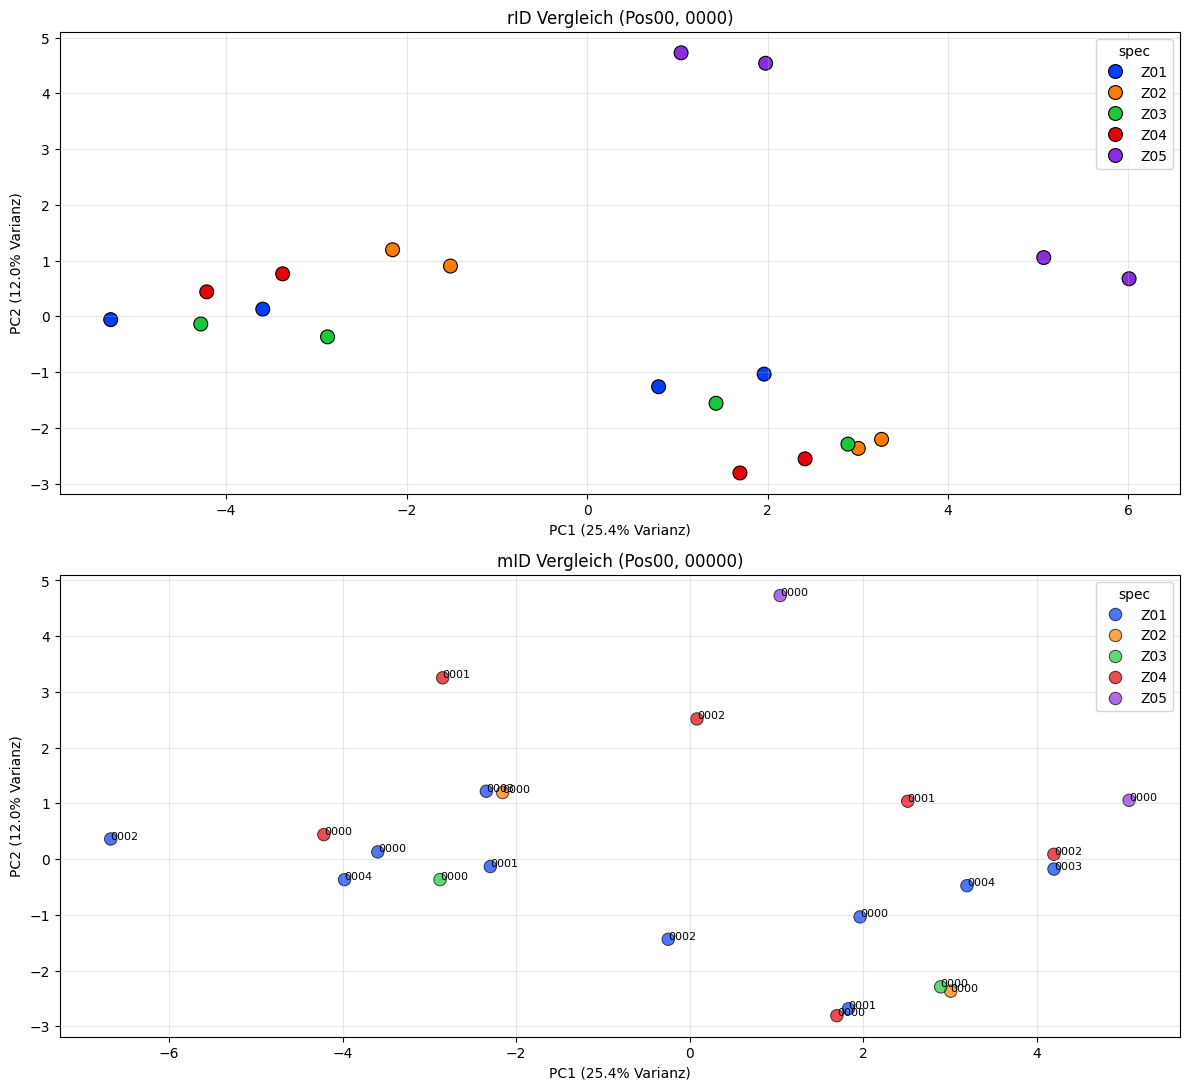

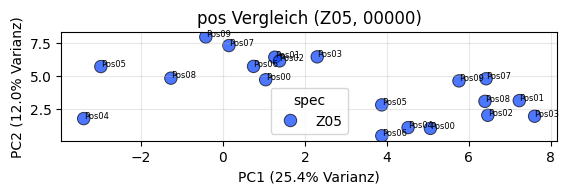

In [6]:
import seaborn as sns
v1, v2 = pca_var_ratio[0], pca_var_ratio[1]
plt.figure(figsize=(12, 16))

zAll = "Z05"
pos = "Pos00"
mID = "0000"
rID = "00000"

# --- Plot 1: rID Vergleich ---
plt.subplot(3, 1, 1)
df_rid = df[(df['pos'] == pos) & (df['mID'] == mID)]
sns.scatterplot(data=df_rid, x='PC1', y='PC2', hue='spec', s=100, palette='bright', edgecolors='k')
plt.title("rID Vergleich (" + pos + ", "+ mID + ")")
plt.xlabel(f"PC1 ({v1:.1f}% Varianz)"); plt.ylabel(f"PC2 ({v2:.1f}% Varianz)")
plt.grid(True, alpha=0.3)

# --- Plot 2: mID Vergleich ---
plt.subplot(3, 1, 2)
df_mid = df[(df['pos'] == pos) & (df['rID'] == rID)]
sns.scatterplot(data=df_mid, x='PC1', y='PC2', hue='spec', s=80, palette='bright', alpha=0.7, edgecolors='k')
for i in range(df_mid.shape[0]):
    plt.text(df_mid.PC1.iloc[i], df_mid.PC2.iloc[i], str(df_mid.mID.iloc[i]), fontsize=8)
plt.title("mID Vergleich (" + pos + ", " + rID + ")")
plt.xlabel(f"PC1 ({v1:.1f}% Varianz)"); plt.ylabel(f"PC2 ({v2:.1f}% Varianz)")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Plot 3: jede Pos eines Zahnrads --- 
plt.subplot(3, 1, 3)
df_zid = df[(df['spec'] == zAll) & (df['rID'] == rID)]
sns.scatterplot(data=df_zid, x='PC1', y='PC2', hue='spec', s=80, palette='bright', alpha=0.7, edgecolors='k')
for i in range(df_zid.shape[0]):
    plt.text(df_zid.PC1.iloc[i], df_zid.PC2.iloc[i], str(df_zid.pos.iloc[i]), fontsize=6)
plt.title("pos Vergleich (" + zAll + ", " + rID + ")")
plt.xlabel(f"PC1 ({v1:.1f}% Varianz)"); plt.ylabel(f"PC2 ({v2:.1f}% Varianz)")
plt.grid(True, alpha=0.3)


### Zelle 4: Detaillierter Vergleich (Kanäle & Positionen)
Kanaltrennung (Ch1 vs. Ch2) über verschiedene Konfigurationen (6 Plots).

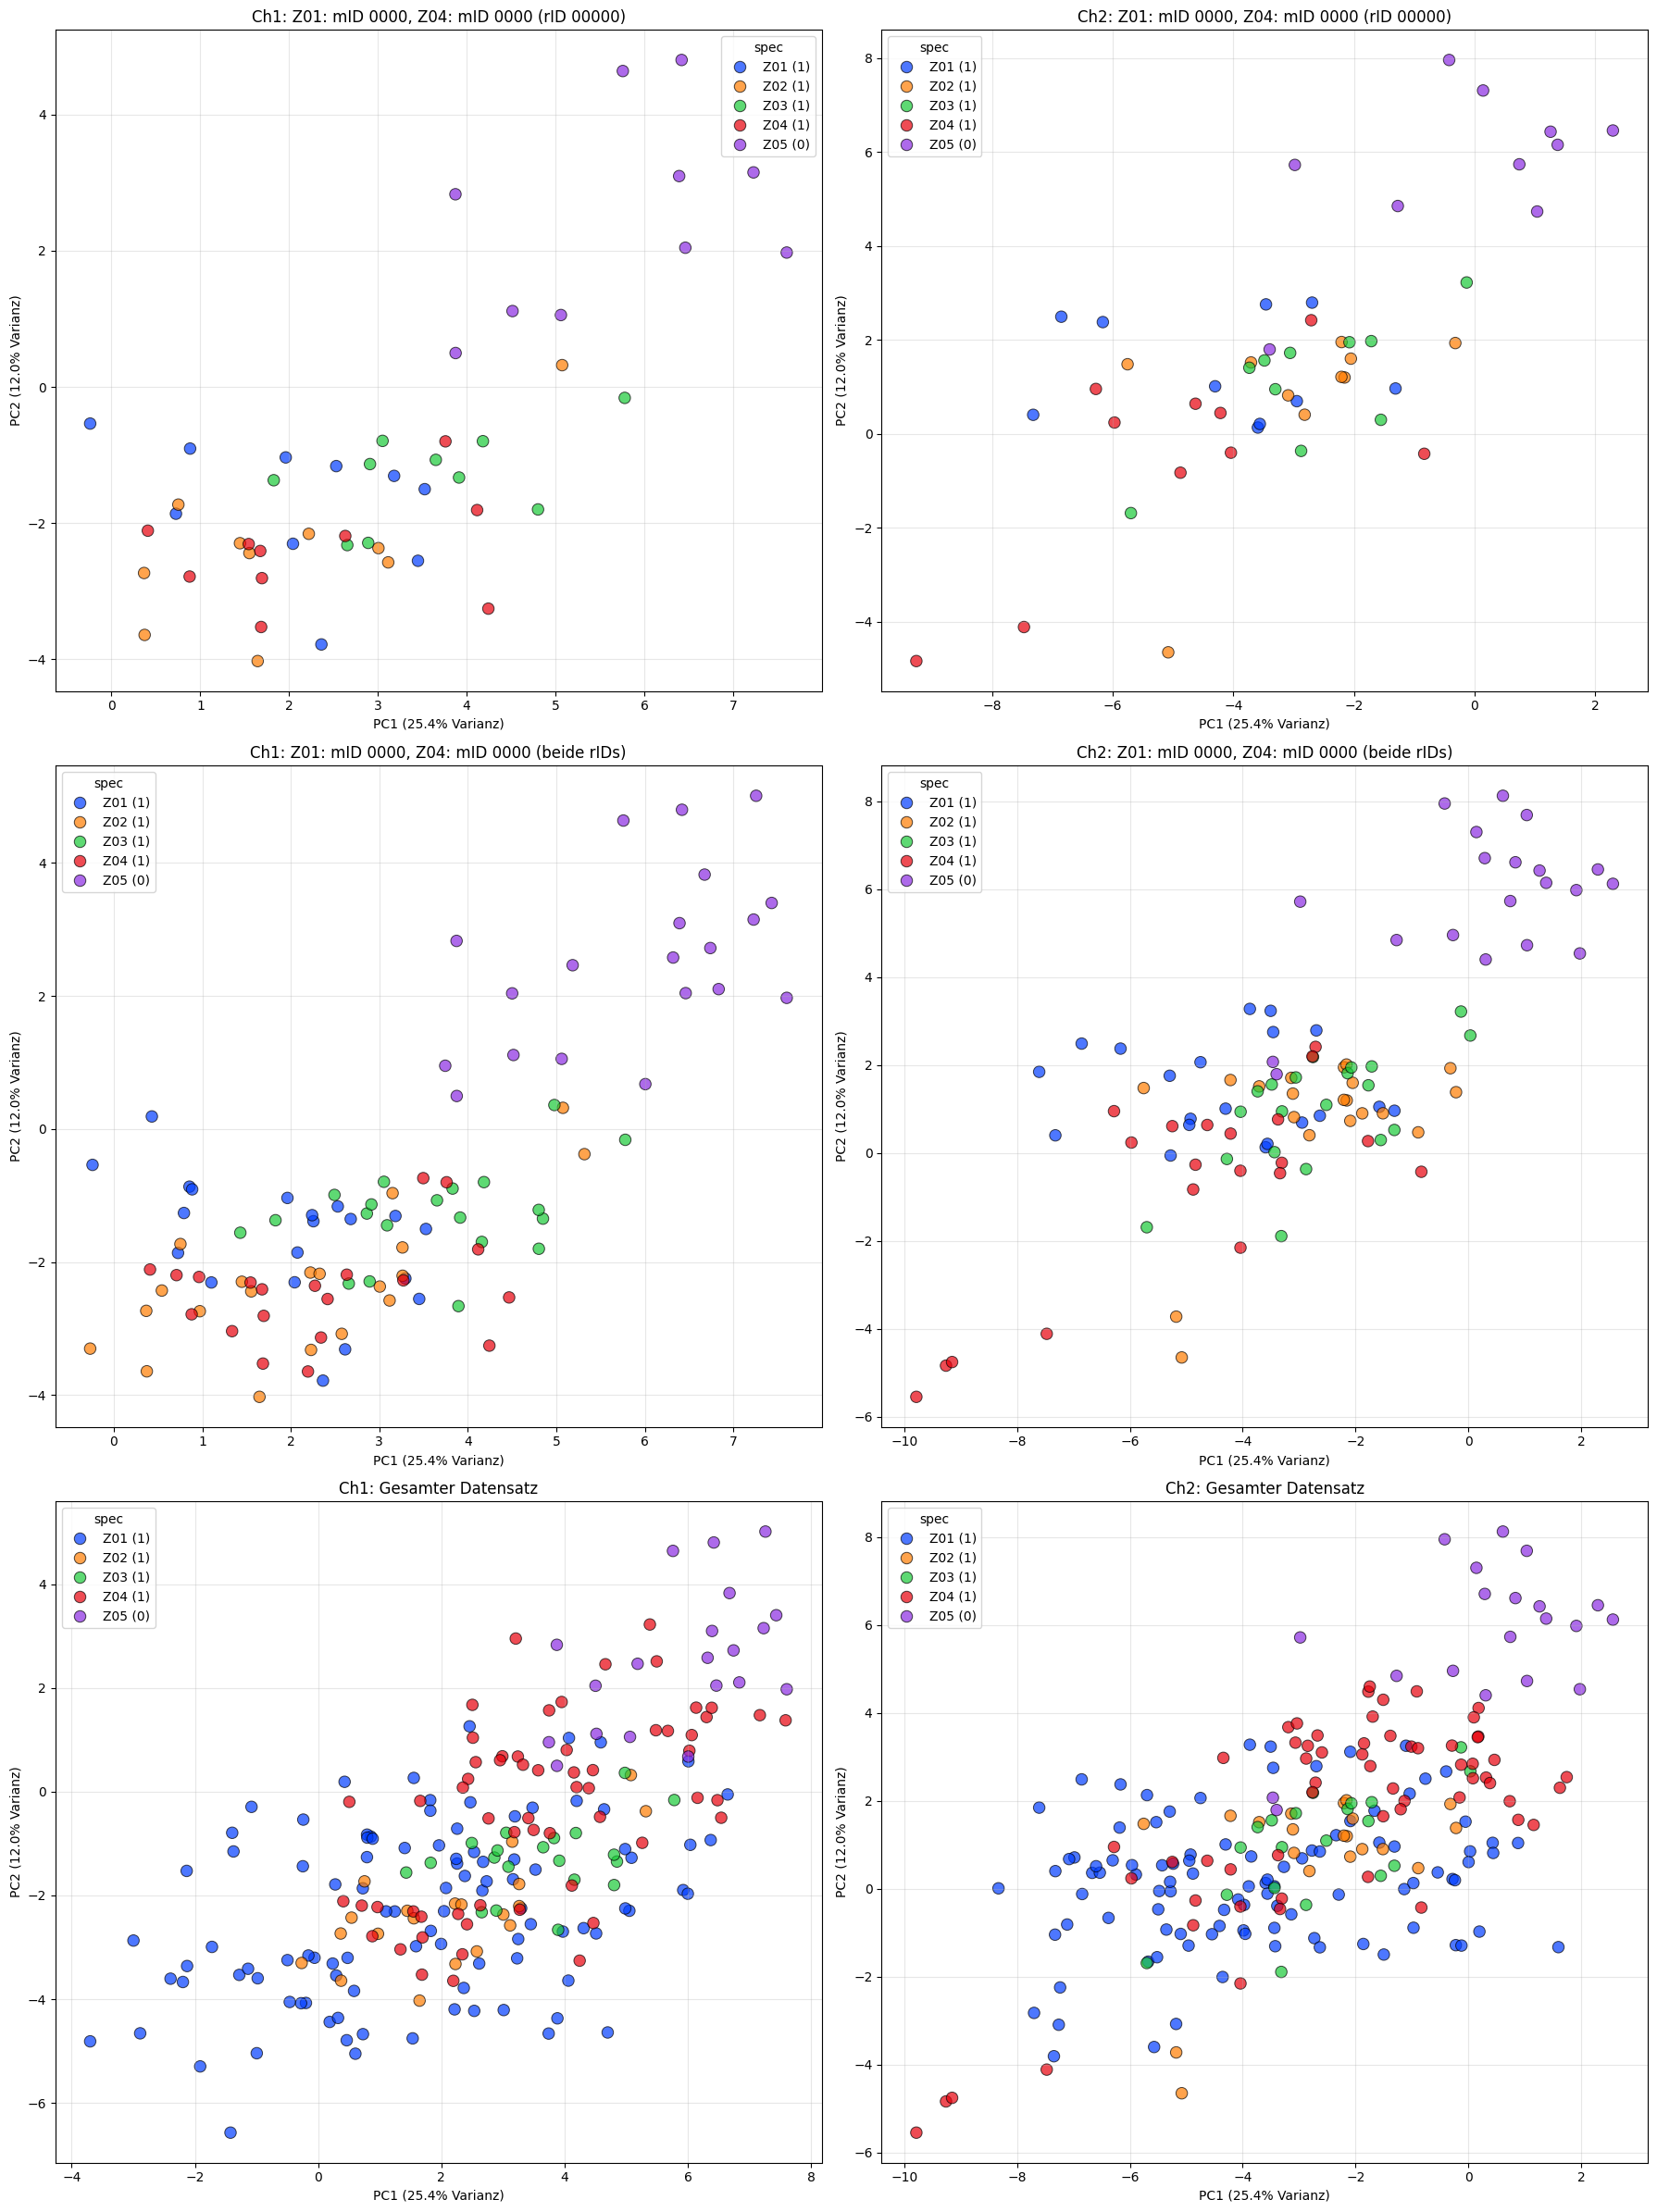

In [20]:
v1, v2 = pca_var_ratio[0], pca_var_ratio[1]
spec_state = {'Z01': '1', 'Z02': '1', 'Z03': '1', 'Z04': '1', 'Z05': '0'}
spec_label = lambda spec: f"{spec} ({spec_state.get(spec, '?')})"

mID_Z1 = "0000"  # aus der Menge "0000" ... "0004"
mID_Z4 = "0000"  # aus der Menge "0000" ... "0002"

plt.figure(figsize=(18, 24))
m_r0 = (df['rID'] == '00000') & (((df['spec'] == 'Z01') & (df['mID'] == mID_Z1)) | ((df['spec'] == 'Z04') & (df['mID'] == mID_Z4)) | (df['spec'].isin(['Z02', 'Z03', 'Z05']) & (df['mID'] == '0000')))
m_br = (((df['spec'] == 'Z01') & (df['mID'] == mID_Z1)) | ((df['spec'] == 'Z04') & (df['mID'] == mID_Z4)) | (df['spec'].isin(['Z02', 'Z03', 'Z05']) & (df['mID'] == '0000')))
configs = [("Z01: mID " + mID_Z1 + ", Z04: mID "+ mID_Z4 +" (rID 00000)", m_r0), ("Z01: mID " + mID_Z1 + ", Z04: mID "+ mID_Z4 +" (beide rIDs)", m_br), ("Gesamter Datensatz", slice(None))]

idx = 1
for title, mask in configs:
    for chan in ['Ch1', 'Ch2']:
        plt.subplot(3, 2, idx)
        df_s = df[mask].copy() if isinstance(mask, pd.Series) else df.copy()
        df_sc = df_s[df_s['sID'] == chan].copy()
        df_sc['spec_label'] = df_sc['spec'].map(spec_label)
        sns.scatterplot(data=df_sc, x='PC1', y='PC2', hue='spec_label', s=80, palette='bright', edgecolors='k', alpha=0.7)
        plt.title(f"{chan}: {title}")
        plt.xlabel(f"PC1 ({v1:.1f}% Varianz)"); plt.ylabel(f"PC2 ({v2:.1f}% Varianz)")
        plt.legend(title='spec')
        plt.grid(True, alpha=0.3); idx += 1
plt.tight_layout(); plt.show()

### Zelle 5: Boxplots der PCA-relevanten Merkmale
Die Boxplots zeigen die Merkmale aus der Feature-Extraktion, die den groessten Beitrag zu den ersten beiden PCA-Achsen leisten. Dafuer werden die PCA-Loadings ausgewertet: Ein hohes Loading bedeutet, dass ein Merkmal die Lage der Punkte in der PCA-Darstellung stark mitbestimmt.

Fuer die Darstellung werden nur vergleichbare Messungen verwendet (`mID == "0000"`, `Ch1` und `Ch2`). Das ist wichtig, weil Z01 und Z04 mehrere `mID`s enthalten. Wenn alle Messreihen gemischt wuerden, koennten Unterschiede zwischen Messwiederholungen faelschlich wie Unterschiede zwischen den Zahnrad-Proben aussehen.

Die konkret verwendeten Merkmale werden direkt unterhalb als Loading-Tabelle ausgegeben und anschliessend als Boxplots dargestellt. Nicht jedes PCA-relevante Merkmal trennt automatisch defekte und intakte Zahnraeder gut sichtbar; `MFCC_10` kann zum Beispiel PCA-relevant sein, aber im Boxplot kaum eine klare Trennung zeigen.

- **MFCC-/Delta-MFCC-Merkmale (z.B. `Delta_MFCC_10`)**: Beschreiben die spektrale Huelle des Signals und deren Veraenderung. Sie koennen Unterschiede im Klangbild bzw. in der Verteilung der Frequenzanteile erfassen, sind einzeln aber oft schwer physikalisch zu interpretieren.
- **Spectral Bandwidth (`Spectral_Bandwidth`)**: Beschreibt, wie breit die Energie um den spektralen Schwerpunkt verteilt ist. Groessere Werte deuten auf breiter verteilte Frequenzanteile hin.
- **Spectral Rolloff (`Spectral_Rolloff`)**: Gibt an, unterhalb welcher Frequenz ein grosser Anteil der spektralen Energie liegt. Das Merkmal reagiert auf Verschiebungen zu hoeheren oder niedrigeren Frequenzbereichen.
- **Spectral Contrast**: Zeigt, wie stark sich spektrale Spitzen von spektralen Taelern unterscheiden. Das kann Hinweise auf ausgepraegte Resonanzen, Stossanteile oder periodische Anregungen geben.
- **Chroma STFT / Chroma CENS (z.B. `Chroma_STFT_04`)**: Fassen Energieanteile in Frequenzklassen zusammen. Bei technischen Signalen sind sie weniger direkt anschaulich als bei Musik, koennen aber wiederkehrende spektrale Muster sichtbar machen.
- **RMS Energy**: Beschreibt die mittlere Signalenergie. Hohe Werte koennen auf staerkere Schwingungen oder Stossanregungen hinweisen.
- **Zero Crossing Rate**: Beschreibt, wie haeufig das Signal das Vorzeichen wechselt. Hohe Werte deuten eher auf schnelle, hochfrequente Signalanteile hin.

,PC1,PC2,PCA_Beitrag
Spectral_Bandwidth,0.213,0.184,7.618
Delta_MFCC_10,-0.188,0.188,7.031
Spectral_Rolloff,0.145,0.276,7.003
Chroma_STFT_04,0.215,0.125,6.956


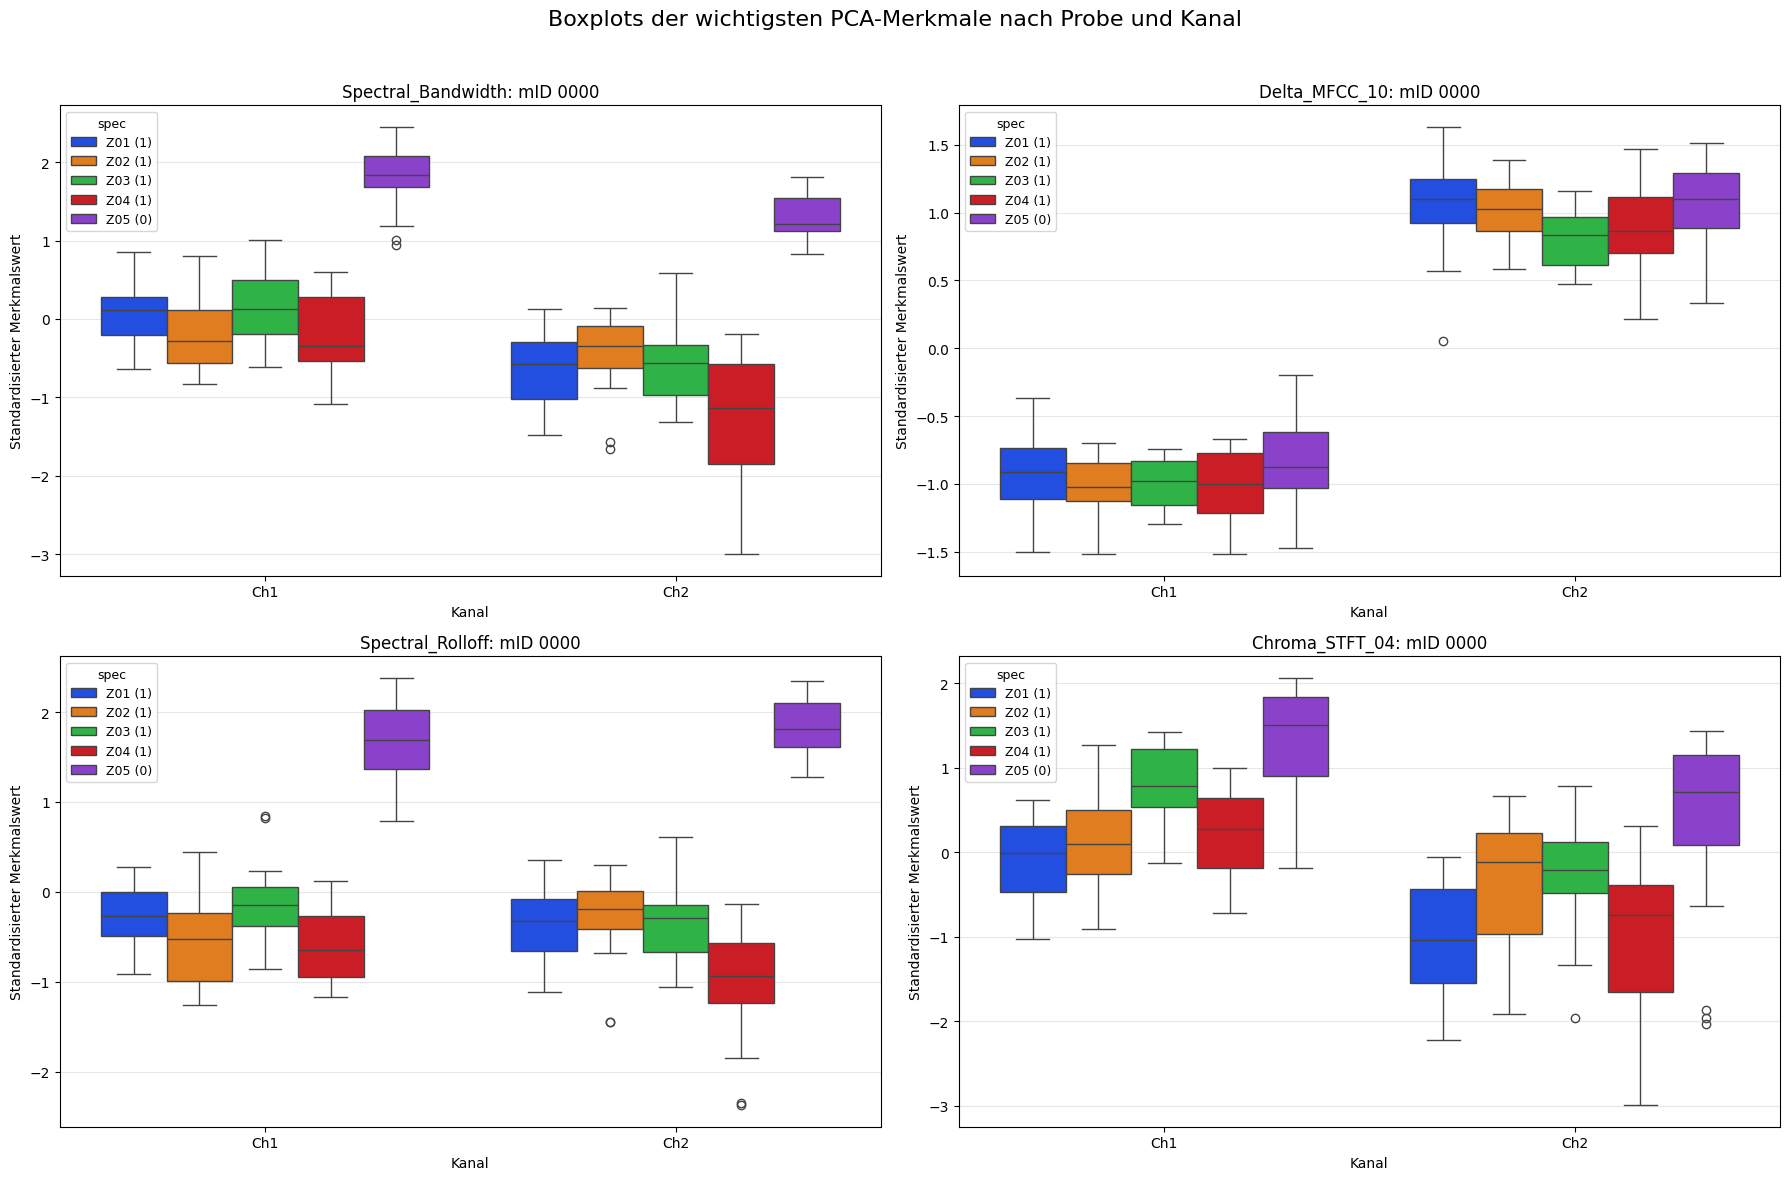

In [6]:
# PCA-Boxplots: Merkmale mit dem groessten Beitrag zu PC1/PC2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

required_vars = ["df", "features_matrix", "pca", "pca_var_ratio"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Bitte zuerst die Datenlade-Zelle und die Feature-/PCA-Zelle ausfuehren. "
        f"Es fehlen: {', '.join(missing_vars)}"
    )

spec_state = {'Z01': '1', 'Z02': '1', 'Z03': '1', 'Z04': '1', 'Z05': '0'}
spec_label = lambda spec: f"{spec} ({spec_state.get(spec, '?')})"

feature_names = (
    [f"MFCC_{i:02d}" for i in range(1, 14)]
    + ["Spectral_Centroid", "Spectral_Bandwidth", "Spectral_Rolloff"]
    + [f"Spectral_Contrast_{i:02d}" for i in range(1, 8)]
    + [f"Chroma_STFT_{i:02d}" for i in range(1, 13)]
    + [f"Chroma_CENS_{i:02d}" for i in range(1, 13)]
    + ["Zero_Crossing_Rate", "RMS_Energy"]
    + [f"Delta_MFCC_{i:02d}" for i in range(1, 14)]
)

X_named = pd.DataFrame(features_matrix, columns=feature_names).apply(pd.to_numeric, errors="coerce").fillna(0)
X_named = X_named.loc[:, X_named.std() > 1e-10]

loadings = pd.DataFrame(pca.components_.T, index=X_named.columns, columns=["PC1", "PC2"])
loadings["PCA_Beitrag"] = (loadings["PC1"].abs() * pca_var_ratio[0]) + (loadings["PC2"].abs() * pca_var_ratio[1])
top_features = loadings.sort_values("PCA_Beitrag", ascending=False).head(4).index.tolist()

display(loadings.loc[top_features].round(3))

analysis_mask = (df["mID"] == "0000") & df["sID"].isin(["Ch1", "Ch2"])
df_box = df.loc[analysis_mask, ["spec", "sID"]].copy()
df_box["spec_label"] = df_box["spec"].map(spec_label)
X_box = X_named.loc[analysis_mask, top_features]

boxplot_data = pd.DataFrame(
    StandardScaler().fit_transform(X_box),
    columns=top_features,
    index=df_box.index,
)
boxplot_data[["spec", "spec_label", "sID"]] = df_box[["spec", "spec_label", "sID"]]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=False)
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    sns.boxplot(
        data=boxplot_data,
        x="sID",
        y=feature,
        hue="spec_label",
        palette="bright",
        ax=ax,
    )
    ax.set_title(f"{feature}: mID 0000")
    ax.set_xlabel("Kanal")
    ax.set_ylabel("Standardisierter Merkmalswert")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="spec", fontsize=9, title_fontsize=9)

fig.suptitle("Boxplots der wichtigsten PCA-Merkmale nach Probe und Kanal", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()